# Transformer Encoder Block


## Architecture Overview

The encoder block consists of two sub-layers, each wrapped with a residual connection and layer normalization.

**Pre-LN formulation** (modern, more stable):
$$\text{SubLayer1}(x) = x + \text{MultiHeadAttention}(\text{LayerNorm}(x))$$
$$\text{SubLayer2}(x) = x + \text{FFN}(\text{LayerNorm}(x))$$

**Post-LN formulation** (original paper):
$$\text{SubLayer1}(x) = \text{LayerNorm}(x + \text{MultiHeadAttention}(x))$$
$$\text{SubLayer2}(x) = \text{LayerNorm}(x + \text{FFN}(x))$$

Pre-LN places normalization inside the residual branch. Post-LN normalizes after the residual addition. Pre-LN is now standard because it produces more stable gradients during training.

## Layer Normalization: Derivation

Given input $x \in \mathbb{R}^{d_{\text{model}}}$, LayerNorm computes:

$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

$$\text{LayerNorm}(x)_i = \gamma_i \hat{x}_i + \beta_i$$

Where:
- $\mu = \frac{1}{d} \sum_{i=1}^{d} x_i$ (mean over features)
- $\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2$ (variance over features)
- $\gamma, \beta \in \mathbb{R}^{d_{\text{model}}}$ are learnable scale and shift parameters
- $\epsilon \approx 10^{-6}$ for numerical stability

**Contrast with BatchNorm:**
- **BatchNorm:** normalize over batch dimension (statistics depend on batch)
- **LayerNorm:** normalize over feature dimension (statistics per-sample) $\rightarrow$ works with variable batch sizes and sequence lengths

## Feed-Forward Network (FFN)

$$\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

Dimensions:
- $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{ff}}$, $b_1 \in \mathbb{R}^{d_{ff}}$
- $W_2 \in \mathbb{R}^{d_{ff} \times d_{\text{model}}}$, $b_2 \in \mathbb{R}^{d_{\text{model}}}$
- Standard: $d_{ff} = 4 \times d_{\text{model}}$

The FFN is applied identically to each position. It acts as a "memory" or "lookup": recent work shows FFN layers store factual knowledge while attention layers route information.

**Modern variants** use GELU or SwiGLU instead of ReLU:
- $\text{GELU}(x) = x \cdot \Phi(x)$ where $\Phi$ is the standard normal CDF
- $\text{SwiGLU}(x) = (xW_1) \odot \sigma(xW_{\text{gate}})$ : used in LLaMA, PaLM

## Residual Connections

Consider a network $f(x) = x + g(x)$ where $g$ is a sub-layer.

Gradient:
$$\frac{\partial f}{\partial x} = I + \frac{\partial g}{\partial x}$$

The identity term $I$ means gradients always flow directly through the residual path, even if $\frac{\partial g}{\partial x}$ is small. This prevents vanishing gradients in deep networks.

For a stack of $L$ residual blocks:

$$\frac{\partial \mathcal{L}}{\partial x_0} = \frac{\partial \mathcal{L}}{\partial x_L} \cdot \prod_{l=0}^{L-1}\left(I + \frac{\partial g_l}{\partial x_l}\right)$$

Expanding: this sum includes a direct path (product of all $I$ terms) plus many shorter paths through subsets of layers. Compare to a plain network: all gradients must flow through every layer sequentially.

## Pre-LN vs Post-LN: Gradient Analysis

**Post-LN:** gradient must pass through LayerNorm at each layer $\rightarrow$ can amplify or attenuate.

**Pre-LN:** the residual path bypasses LayerNorm $\rightarrow$ gradient flows unimpeded through the skip connection.

Empirically:
- Post-LN requires learning rate warmup to avoid divergence
- Pre-LN trains stably even without warmup
- Post-LN can achieve slightly better final performance with careful tuning
- Modern practice: Pre-LN (simpler to train)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Reuse from previous notebooks
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        Q = self.W_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(attn_output), attn_weights

## Implementation

In [2]:
class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.
    
    Args:
        d_model: input/output dimension
        d_ff: hidden dimension (typically 4 * d_model)
        dropout: dropout rate
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        # TODO: Two linear layers with ReLU activation and dropout
        # Linear(d_model, d_ff) -> ReLU -> Dropout -> Linear(d_ff, d_model) -> Dropout
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        return self.net(x)

In [3]:
class TransformerEncoderBlock(nn.Module):
    """
    Single Transformer encoder block (Pre-LN variant).
    
    Architecture:
        x -> LayerNorm -> MultiHeadAttention -> + (residual) -> 
             LayerNorm -> FeedForward -> + (residual)
    
    Args:
        d_model: model dimension
        n_heads: number of attention heads
        d_ff: feed-forward hidden dimension
        dropout: dropout rate
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: optional attention mask
        Returns:
            (batch, seq_len, d_model)
        """
        # Sub-layer 1: Pre-LN self-attention with residual
        # norm -> attention -> dropout -> add residual
        normed = self.norm1(x)
        attn_output, _ = self.attention(normed, normed, normed, mask)
        attn_output = self.dropout(attn_output)
        x = x + attn_output  # residual connection
        
        # Sub-layer 2: Pre-LN FFN with residual
        normed = self.norm2(x)
        ff_output = self.feed_forward(normed)
        x = x + ff_output  # residual connection
        
        return x

## Verification

In [4]:
d_model, n_heads, d_ff = 64, 8, 256
block = TransformerEncoderBlock(d_model, n_heads, d_ff)

x = torch.randn(2, 10, d_model)
output = block(x)

assert output.shape == x.shape, f"Expected {x.shape}, got {output.shape}"

# Count parameters
total_params = sum(p.numel() for p in block.parameters())
attn_params = 4 * d_model * d_model + 4 * d_model  # 4 projections + biases
ff_params = d_model * d_ff + d_ff + d_ff * d_model + d_model  # 2 linear layers + biases
ln_params = 2 * (2 * d_model)  # 2 LayerNorms, each with gamma + beta
expected = attn_params + ff_params + ln_params

print(f"Total parameters: {total_params}")
print(f"Expected: {expected}")
print(f"  Attention: {attn_params}")
print(f"  FeedForward: {ff_params}")
print(f"  LayerNorm: {ln_params}")

# Stack multiple blocks
n_layers = 6
encoder = nn.Sequential(*[TransformerEncoderBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
deep_output = encoder(x)
assert deep_output.shape == x.shape
print(f"\n6-layer encoder parameters: {sum(p.numel() for p in encoder.parameters())}")
print("All checks passed.")

Total parameters: 49984
Expected: 49984
  Attention: 16640
  FeedForward: 33088
  LayerNorm: 256

6-layer encoder parameters: 299904
All checks passed.


## Experiment: Gradient Flow: Residual Connections

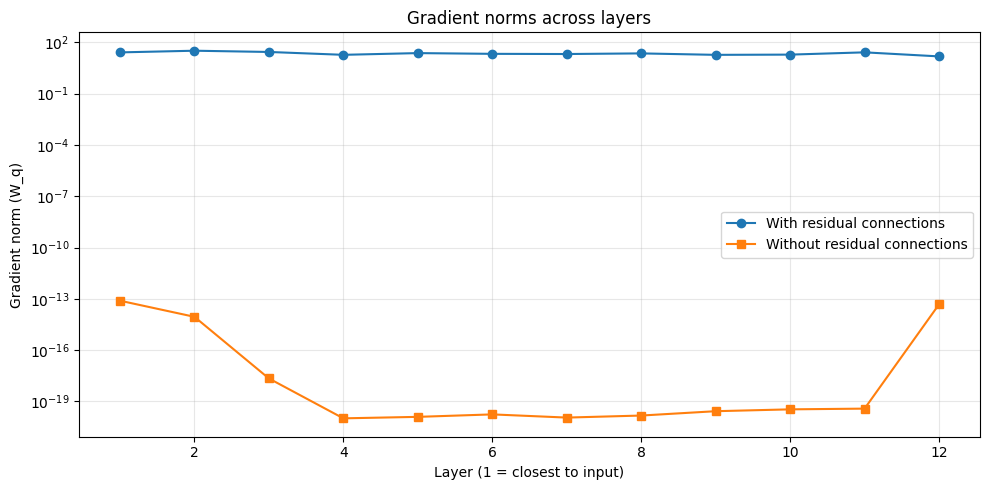

Gradient ratio (layer 1 / layer 12):
  With residual:    1.72x
  Without residual: 1.63x


In [5]:
# Compare gradient magnitudes with and without residual connections

class BlockNoResidual(nn.Module):
    """Encoder block WITHOUT residual connections for comparison."""
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout=0.0)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x, mask=None):
        x = self.norm1(self.attention(x, x, x, mask)[0])  # no residual
        x = self.norm2(self.feed_forward(x))               # no residual
        return x

def measure_gradient_norms(model_class, n_layers, d_model=64, n_heads=4, d_ff=256):
    blocks = nn.ModuleList([model_class(d_model, n_heads, d_ff) for _ in range(n_layers)])
    
    x = torch.randn(1, 10, d_model, requires_grad=True)
    
    # Forward pass, storing intermediate activations
    h = x
    for block in blocks:
        h = block(h)
    
    loss = h.sum()
    loss.backward()
    
    # Collect gradient norms from each block's attention weights
    grad_norms = []
    for block in blocks:
        grad_norm = block.attention.W_q.weight.grad.norm().item()
        grad_norms.append(grad_norm)
    
    return grad_norms

n_layers = 12
grad_with_residual = measure_gradient_norms(TransformerEncoderBlock, n_layers)
grad_no_residual = measure_gradient_norms(BlockNoResidual, n_layers)

fig, ax = plt.subplots(figsize=(10, 5))
layers = range(1, n_layers + 1)
ax.plot(layers, grad_with_residual, 'o-', label='With residual connections')
ax.plot(layers, grad_no_residual, 's-', label='Without residual connections')
ax.set_xlabel('Layer (1 = closest to input)')
ax.set_ylabel('Gradient norm (W_q)')
ax.set_title('Gradient norms across layers')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gradient ratio (layer 1 / layer {n_layers}):")
print(f"  With residual:    {grad_with_residual[0] / grad_with_residual[-1]:.2f}x")
print(f"  Without residual: {grad_no_residual[0] / grad_no_residual[-1]:.2f}x")

## Connections

- The encoder block is the fundamental unit of BERT, ViT (Vision Transformer), and the encoder half of T5
- BERT-base: 12 blocks, $d_{\text{model}}=768$, 12 heads, $d_{ff}=3072$ $\rightarrow$ 110M parameters
- GPT-2: same block structure but with causal masking (decoder blocks)
- Modern LLMs (LLaMA): replace ReLU FFN with SwiGLU, use RMSNorm instead of LayerNorm, use RoPE instead of absolute PE
- The ratio $d_{ff}/d_{\text{model}} = 4$ is from the original paper. Some recent models use $\frac{8}{3} \times d_{\text{model}}$ with SwiGLU to keep parameter count similar
- **Next notebook:** assembling the full encoder with embedding layer and training on SST-2

## Key Equations

Pre-LN Encoder Block:
$$x = x + \text{MHA}(\text{LN}(x))$$
$$x = x + \text{FFN}(\text{LN}(x))$$

FFN:
$$\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

LayerNorm:
$$\text{LN}(x)_i = \gamma_i \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta_i$$